# C1: Search Extensions

**FIT1061 Introduction to Artificial Intelligence — Credit Task 1**

You've built BFS (P2), DFS (P2), greedy best-first (P3), and hill climbing (P4). Each solves problems differently — and each has blind spots. This task asks you to extend, fix, and compare them.

You'll make hill climbing reliable with random restarts and investigate how graph structure affects algorithm performance.

> **Prerequisites:** P4 (Ready for Feedback). You'll reuse code from P2–P4.

> **Credit level:** Less scaffolding than PASS tasks. Function signatures are provided; implementations are up to you.


---

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

# Import C1 helpers. The 8-queens board primitives (random_board,
# count_violations, get_neighbours, visualise_board) are bundled here too,
# so C1 runs from its own download alone — no P4 folder needed.
from c1_helpers import (GRAPH_CONFIGS, visualise_graph, path_cost,
                        plot_restarts_curve, random_board, count_violations,
                        get_neighbours, visualise_board)

print("Setup OK.")


Setup OK.


---

## C1.1: Random Restarts: Making Hill Climbing Reliable

In P4, you saw that hill climbing often gets stuck in local minima. Random restarts fix this: if you get stuck, start over from a new random state and try again.

### Step 1: Measure the problem

First, let's see how often plain hill climbing fails.

In [2]:
# Adapt your hill_climbing function from P4 for use here.
#
# YOUR P4 FUNCTION returned (final_board, violations_log) — a 2-tuple.
# HERE we need (state, history, solved) — a 3-TUPLE with a boolean.
# We've renamed it hill_climbing_queens to distinguish it from your P4 version.
#
# What to change from your P4 code:
#   1. Generate a random starting board inside the function (using random_board(n))
#   2. Return a 3-tuple: (final_state, history, solved)
#      where solved = True if count_violations(final_state) == 0
#   3. history should be a list of (state, violations) tuples
#
# IMPORTANT: get_neighbours() returns (new_board, row, new_col)
# tuples, not bare boards. When finding the best neighbour, unpack:
#   best_board, _, _ = min(neighbours, key=lambda x: count_violations(x[0]))

def hill_climbing_queens(n, max_steps=100, seed=None):
    """Hill climbing for n-queens. Returns (state, history, solved)."""
    # --- YOUR CODE HERE ---
    # Reuse your P4 implementation, adapted as described above.
    board=random_board(n)
    current = list(board)  # Make a copy
    violations_log = []
    solved= False
    for step in range(max_steps):
        current_v = count_violations(current)
        violations_log.append(current_v)

        # If solved, stop
        if current_v == 0:
            break

        # --- YOUR CODE HERE ---
        # 1. Find the best neighbour (lowest violations).
        #    Hint: loop through get_neighbours(current), track the
        #    neighbour with the fewest violations.
        neighbours = get_neighbours(current)
        current_v = count_violations(current)
        best_board = None
        best_v = current_v
        for new_board,row, col in get_neighbours(current):
            v = count_violations(new_board)
            if v < best_v:
                best_v = v
                best_board = new_board
        
        #
        # 2. If the best neighbour has fewer violations than current,
        #    update current to be that neighbour.
        #
        # 3. If no neighbour is better, break (local minimum).
        if best_board is None:
            break
        current= best_board
    if best_v==0: 
        solved= True
    return current, violations_log, solved
    # --- END YOUR CODE ---


# Run 200 trials and measure success rate
n_trials = 200
successes = 0
stuck_at = []

np.random.seed(42)
for trial in range(n_trials):
    result = hill_climbing_queens(n=8)
    if result is None:
        print("\u26a0 hill_climbing_queens returned None \u2014 implement it first!")
        break
    state, history, solved = result
    if solved:
        successes += 1
    else:
        stuck_at.append(count_violations(state))
else:
    plain_rate = successes / n_trials
    print(f"Plain hill climbing: {successes}/{n_trials} solved ({plain_rate:.0%})")
    print(f"Stuck cases: {len(stuck_at)}, typical violations when stuck: {np.median(stuck_at) if stuck_at else 'N/A'}")

Plain hill climbing: 22/200 solved (11%)
Stuck cases: 178, typical violations when stuck: 1.0


### Step 2: Implement random restarts

In [3]:
def hill_climbing_with_restarts(n, max_restarts, max_steps_per_restart=100):
    """Hill climbing with random restarts for n-queens.

    If a single run gets stuck, start over with a new random board.
    Stop as soon as a solution is found or max_restarts is reached.

    Args:
        n: Board size.
        max_restarts: Maximum number of restarts.
        max_steps_per_restart: Max steps per individual run.

    Returns:
        (best_state, restarts_used, solved)
    """
    # --- YOUR CODE HERE ---
    board=random_board(n)
    current = list(board)  # Make a copy
    violations_log = []
    solved= False
    for step in range(max_steps_per_restart):
        if max_restarts==0:
            break

        current_v = count_violations(current)
        violations_log.append(current_v)

        # If solved, stop
        if current_v == 0:
            break

        # --- YOUR CODE HERE ---
        # 1. Find the best neighbour (lowest violations).
        #    Hint: loop through get_neighbours(current), track the
        #    neighbour with the fewest violations.
        neighbours = get_neighbours(current)
        current_v = count_violations(current)
        best_board = None
        best_v = current_v
        for new_board,row, col in get_neighbours(current):
            v = count_violations(new_board)
            if v < best_v:
                best_v = v
                best_board = new_board
                current= best_board
        # 2. If the best neighbour has fewer violations than current,
        #    update current to be that neighbour.
        #
        # 3. If no neighbour is better, break (local minimum).
        if best_v==0: 
            solved=True
            return current, violations_log, solved

        if best_board is None:
            current=random_board()
            max_steps_per_restart=100
            max_restarts-=1
        
    if best_v==0: 
        solved= True
    return current, violations_log, solved

    # --- END YOUR CODE ---


# Quick test
result = hill_climbing_with_restarts(n=8, max_restarts=50)
if result is None:
    print("⚠ hill_climbing_with_restarts returned None — implement it first!")
else:
    state, restarts, solved = result
    print(f"Solved: {solved}, restarts used: {restarts}")
    if solved:
        print(f"Violations: {count_violations(state)}")
        visualise_board(state, title=f"Solved with {restarts} restarts")

Solved: False, restarts used: [5, 2, 1, 9, 5, 3, 2, 1, 7, 4, 3, 2, 1, 10, 6, 3, 2, 1, 10, 7, 4, 2, 1, 10, 5, 3, 2, 11, 7, 4, 2, 11, 7, 5, 3, 1, 9, 5, 2, 1, 5, 3, 1, 6, 4, 3, 7, 5, 3, 2, 6, 4, 3, 2, 1, 6, 3, 2, 1, 8, 5, 4, 2, 1, 7, 5, 3, 2, 12, 7, 4, 3, 2, 12, 8, 5, 3, 2, 1, 9, 5, 3, 2, 10, 6, 3, 2, 10, 6, 3, 2, 1, 10, 6, 4, 2, 15, 10, 6, 3]


### Step 3: Success rate vs number of restarts

Test how many restarts are needed for reliable solutions.

  max_restarts=  1: 16%
  max_restarts=  5: 44%
  max_restarts= 10: 84%
  max_restarts= 20: 92%
  max_restarts= 50: 98%
  max_restarts=100: 97%


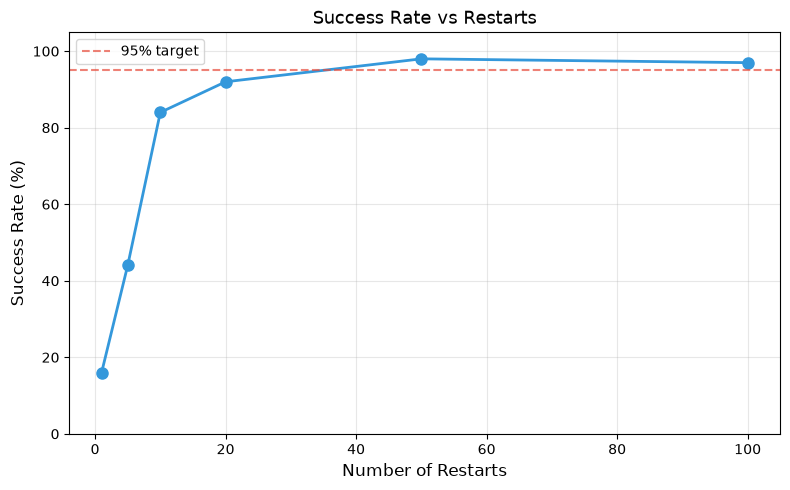


>95% reliability achieved with 50 restarts.


In [4]:
restart_counts = [1, 5, 10, 20, 50, 100]
success_rates = []
n_trials = 100

# Check that hill_climbing_with_restarts is implemented
test = hill_climbing_with_restarts(n=8, max_restarts=1)
if test is None:
    print("⚠ hill_climbing_with_restarts returned None — implement it first!")
else:
    for max_r in restart_counts:
        solved_count = 0
        for _ in range(n_trials):
            _, _, solved = hill_climbing_with_restarts(n=8, max_restarts=max_r)
            if solved:
                solved_count += 1
        rate = solved_count / n_trials
        success_rates.append(rate)
        print(f"  max_restarts={max_r:>3d}: {rate:.0%}")

    plot_restarts_curve(restart_counts, success_rates)

    # How many restarts for >95%?
    for r, s in zip(restart_counts, success_rates):
        if s >= 0.95:
            print(f"\n>95% reliability achieved with {r} restarts.")
            break

---

## C1.2: Multi-Graph Comparison: How Structure Shapes Search

BFS, DFS, and greedy best-first search behave very differently depending on the graph they're searching. A sparse tree-like graph, a dense graph with many paths, and a graph with a misleading heuristic each reveal different strengths and weaknesses.

In this section you'll run **your BFS, DFS, and greedy implementations** on three carefully chosen graphs and analyse how their performance changes.

### The three graphs

We've provided three graphs, each with a start node `S` and goal `G`:

1. **Sparse:** tree-like, few edges, essentially one path each way.
2. **Dense:** many connections between nodes, multiple paths of varying cost.
3. **Misleading:** the heuristic makes one direction look promising, but the actual shortest path goes the other way.

Let's visualise them.


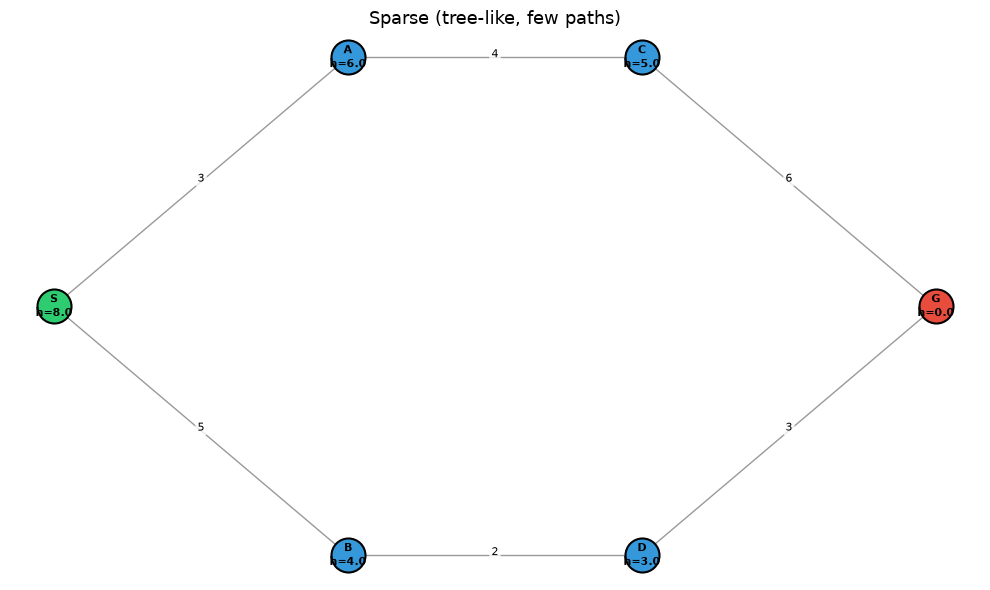

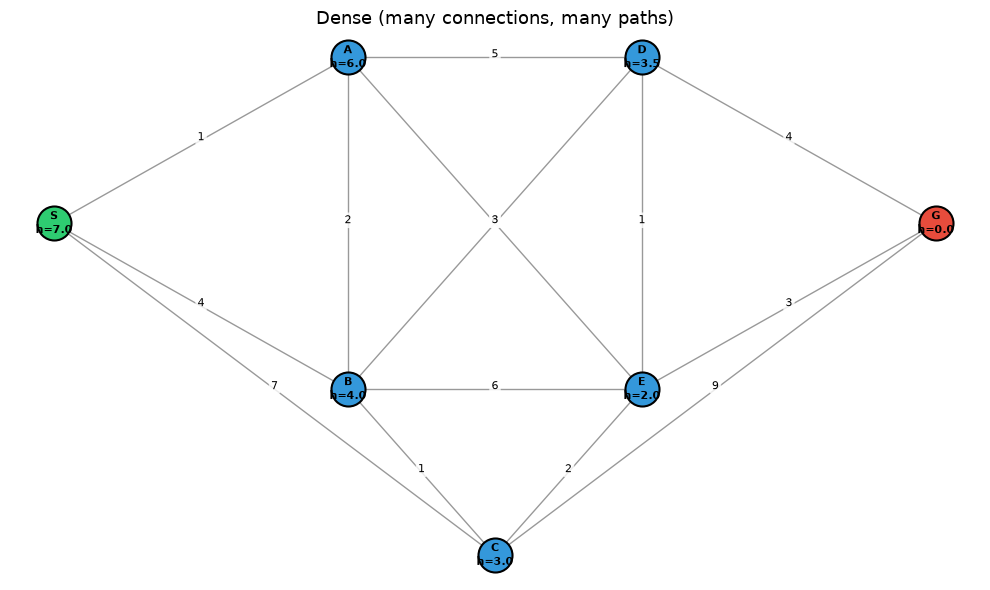

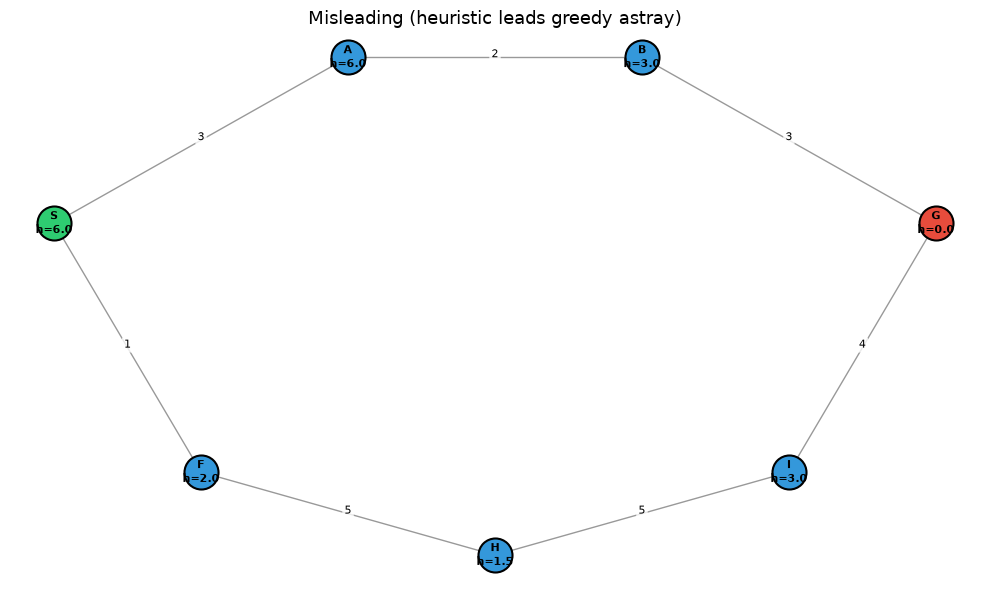

In [5]:
# Visualise all three graphs
for name, cfg in GRAPH_CONFIGS.items():
    visualise_graph(cfg['graph'], cfg['positions'],
                    heuristic=cfg['heuristic'],
                    start=cfg['start'], goal=cfg['goal'],
                    title=f"{cfg['description']}")

### Implement BFS, DFS, and greedy for general graphs

Adapt your P2 (BFS/DFS) and P3 (greedy best-first) code to work on these weighted graphs. Each should return the **path** found and the **number of nodes expanded**.

> **What changes from P2/P3:**
> - **Input:** Instead of a `GridWorld` object, you receive a **dict of dicts**: `graph[node]` gives `{neighbour: weight, ...}`. Iterate with `for neighbour in graph[current_node]:` instead of `grid_world.get_neighbours(row, col)`.
> - **Return:** Return a **2-tuple** `(path, nodes_expanded)`, not the 3-tuple from P2/P3. You don't need the `explored` set here.
> - **Nodes:** Instead of `(row, col)` tuples, nodes are strings like `'S'`, `'A'`, `'G'`.

Here's what iterating over an adjacency dict looks like:
```python
# graph['S'] returns {'A': 3, 'F': 1}
for neighbour in graph['S']:
    print(neighbour)  # prints 'A', then 'F'
```
The weights are stored as values but BFS and DFS ignore them (they only count edges). Greedy ignores edge weights too; it chooses by heuristic value.

> **Important:** BFS finds the path with the **fewest edges**, not the lowest total cost. DFS and greedy do not guarantee either the fewest-edge path or the lowest-cost path. On weighted graphs, fewer edges does not always mean lower cost. You'll see this in your comparison results.


In [6]:
import queue
import heapq
def path_reconstruct(came_from, start, goal): 
    if goal not in came_from: 
        return None
    path=[]
    current=goal
    while current is not None:
        path.append(current)
        current= came_from[current]
    path.reverse()
    return path 

def bfs_search(graph, start, goal):
    """BFS on a weighted graph. Returns (path, nodes_expanded).

    Args:
        graph: Dict of dicts {node: {neighbour: weight}}.
        start: Start node name.
        goal: Goal node name.

    Returns:
        (path as list of nodes, number of nodes expanded)
    """
    # --- YOUR CODE HERE ---
    if start==goal:
        return([start],0)
    frontier=queue.Queue()
    frontier.put(start)
    viewed= set()
    viewed.add(start)
    came_from={start: None}
    node_expanded=0
    while not frontier.empty():
        current=frontier.get()
        node_expanded+=1
        for neighbour in graph.get(current,{}): 
            if neighbour not in viewed:
                frontier.put(neighbour)
                came_from[neighbour]= current
                viewed.add(neighbour)
                if neighbour==goal:
                    return (path_reconstruct(came_from, start,goal), node_expanded)
    return (path_reconstruct(came_from, start,goal), node_expanded)

    # --- END YOUR CODE ---


def dfs_search(graph, start, goal):
    """DFS on a weighted graph. Returns (path, nodes_expanded).

    Args:
        graph: Dict of dicts {node: {neighbour: weight}}.
        start: Start node name.
        goal: Goal node name.

    Returns:
        (path as list of nodes, number of nodes expanded)
    """
    # --- YOUR CODE HERE ---
    if start==goal:
        return([start],0)
    frontier=[]
    frontier.append(start)
    viewed= set()
    viewed.add(start)
    came_from={start: None}
    node_expanded=0
    while len(frontier) !=0:
        current=frontier.pop()
        node_expanded+=1
        for neighbour in graph.get(current,{}): 
            if neighbour not in viewed:
                frontier.append(neighbour)
                came_from[neighbour]= current
                viewed.add(neighbour)
                if neighbour==goal:
                    return (path_reconstruct(came_from, start,goal), node_expanded)
    return (path_reconstruct(came_from, start,goal), node_expanded)


    # --- END YOUR CODE ---


import heapq

def greedy_search(graph, start, goal, heuristic):
    """Greedy best-first search on a weighted graph. Returns (path, nodes_expanded).

    Args:
        graph: Dict of dicts {node: {neighbour: weight}}.
        start: Start node name.
        goal: Goal node name.
        heuristic: Dict mapping each node to estimated distance to goal.

    Returns:
        (path as list of nodes, number of nodes expanded)
    """
    # --- YOUR CODE HERE ---
    if start==goal:
        return([start],0)
    frontier=[]
    heapq.heappush(frontier,(heuristic[start], start))
    viewed= set()
    came_from={start: None}
    node_expanded=0
    while len(frontier)!=0:
        current_val, current=heapq.heappop(frontier)
        if current in viewed :
            continue
        viewed.add(current)
        node_expanded+=1
        if current==goal:
            return (path_reconstruct(came_from, start,goal), node_expanded)
        for neighbour in graph.get(current,{}): 
            if neighbour not in viewed:
                if neighbour not in came_from:
                    came_from[neighbour]= current
            heapq.heappush(frontier,(heuristic[neighbour], neighbour))

    return (path_reconstruct(came_from, start,goal), node_expanded)
    # --- END YOUR CODE ---


### Run all three algorithms on all three graphs

In [7]:
# Run BFS, DFS, and greedy on each graph, collect results
results = {}
_not_implemented = False

for name, cfg in GRAPH_CONFIGS.items():
    g = cfg['graph']
    h = cfg['heuristic']
    s, goal = cfg['start'], cfg['goal']

    result_b = bfs_search(g, s, goal)
    result_d = dfs_search(g, s, goal)
    result_g = greedy_search(g, s, goal, h)

    if result_b is None or result_d is None or result_g is None:
        print("⚠ bfs_search, dfs_search, or greedy_search returned None — implement them first!")
        _not_implemented = True
        break

    path_b, exp_b = result_b
    path_d, exp_d = result_d
    path_g, exp_g = result_g

    results[name] = {
        'bfs_path': path_b, 'bfs_expanded': exp_b, 'bfs_cost': path_cost(g, path_b),
        'dfs_path': path_d, 'dfs_expanded': exp_d, 'dfs_cost': path_cost(g, path_d),
        'greedy_path': path_g, 'greedy_expanded': exp_g, 'greedy_cost': path_cost(g, path_g),
    }

    print(f"\n=== {cfg['description']} ===")
    print(f"  BFS:    path={path_b}, cost={path_cost(g, path_b)}, expanded={exp_b}")
    print(f"  DFS:    path={path_d}, cost={path_cost(g, path_d)}, expanded={exp_d}")
    print(f"  Greedy: path={path_g}, cost={path_cost(g, path_g)}, expanded={exp_g}")



=== Sparse (tree-like, few paths) ===
  BFS:    path=['S', 'A', 'C', 'G'], cost=13, expanded=4
  DFS:    path=['S', 'B', 'D', 'G'], cost=10, expanded=3
  Greedy: path=['S', 'B', 'D', 'G'], cost=10, expanded=4

=== Dense (many connections, many paths) ===
  BFS:    path=['S', 'C', 'G'], cost=16, expanded=4
  DFS:    path=['S', 'C', 'G'], cost=16, expanded=2
  Greedy: path=['S', 'C', 'G'], cost=16, expanded=3

=== Misleading (heuristic leads greedy astray) ===
  BFS:    path=['S', 'A', 'B', 'G'], cost=8, expanded=4
  DFS:    path=['S', 'F', 'H', 'I', 'G'], cost=15, expanded=4
  Greedy: path=['S', 'F', 'H', 'I', 'G'], cost=15, expanded=5


### Visualise the paths

Look at the paths each algorithm found on each graph. Pay particular attention to the misleading graph.

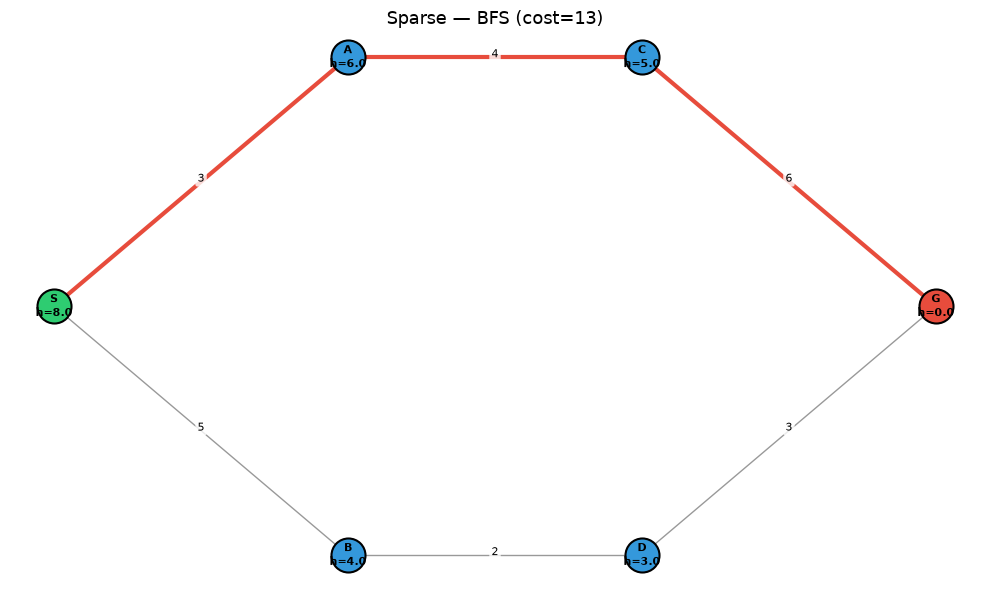

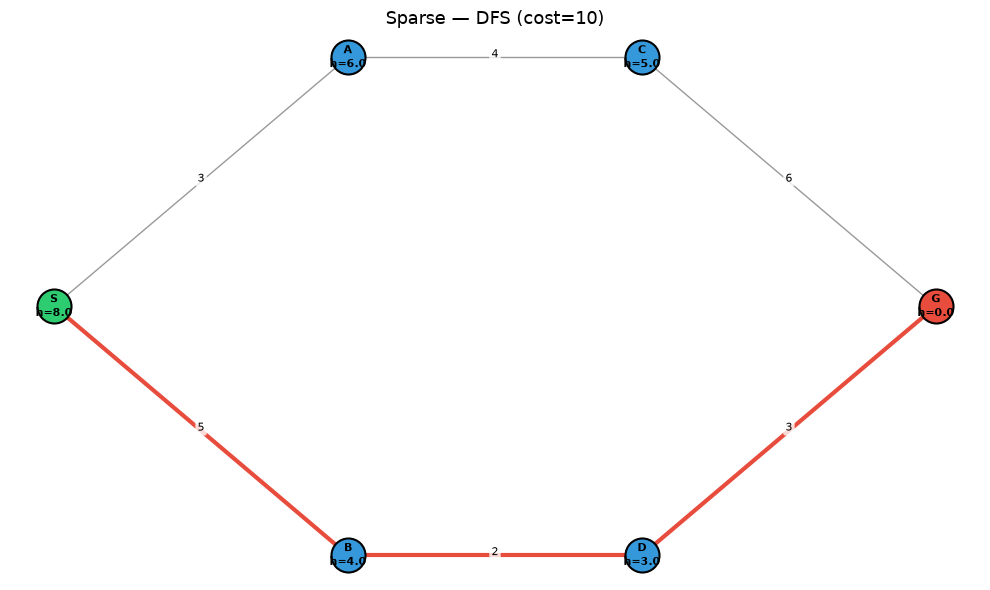

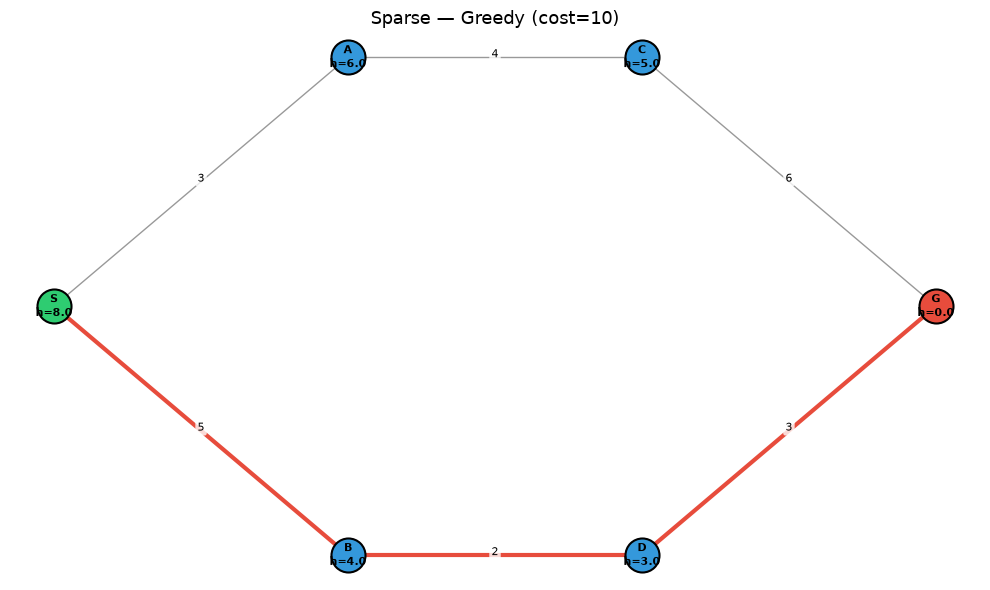

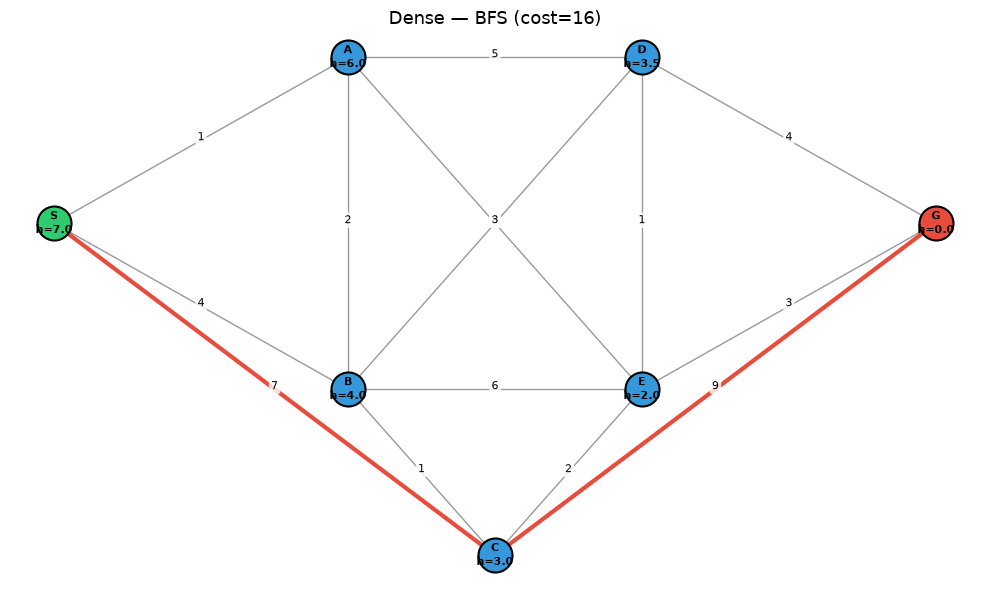

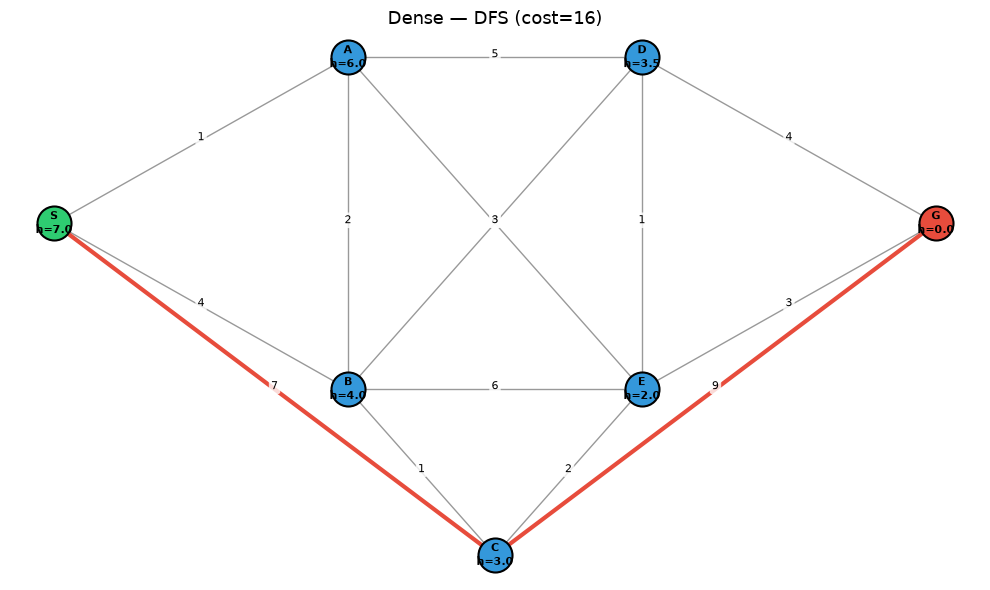

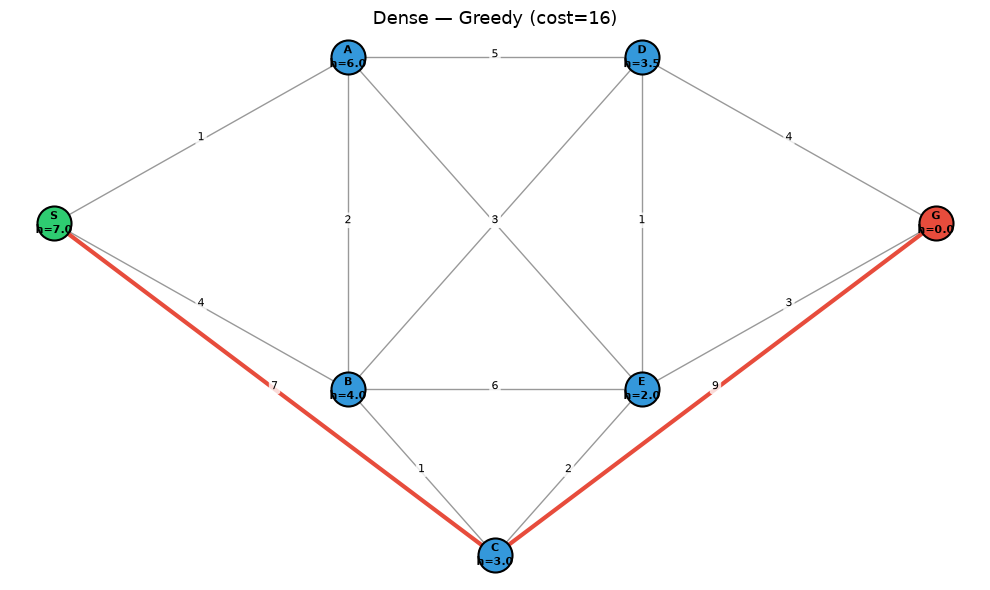

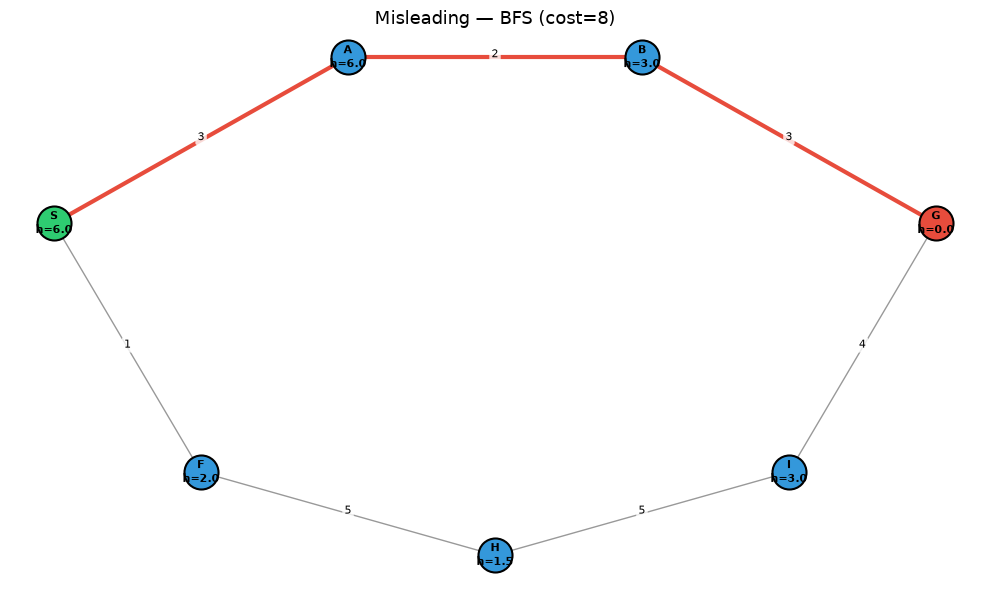

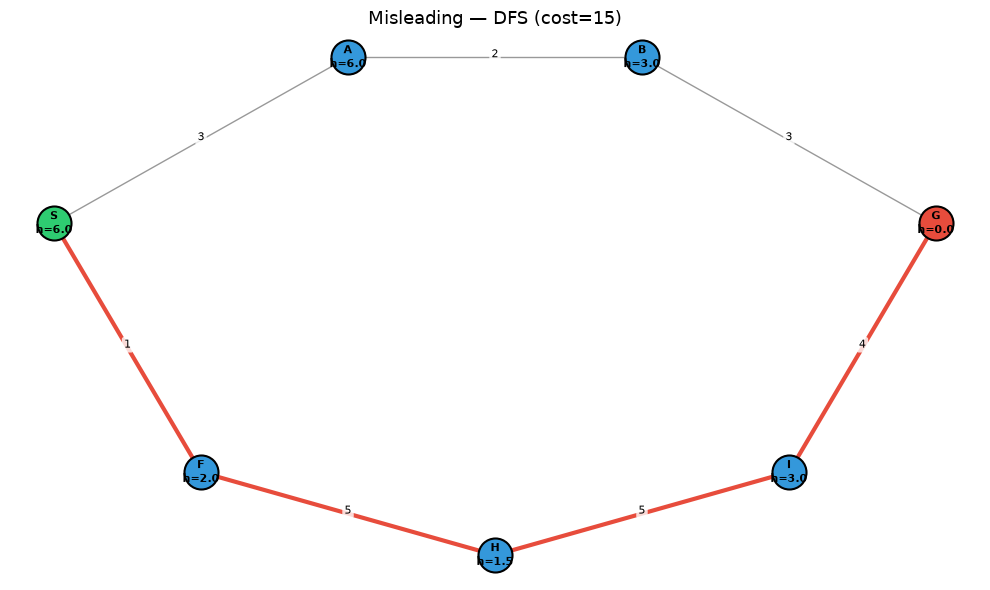

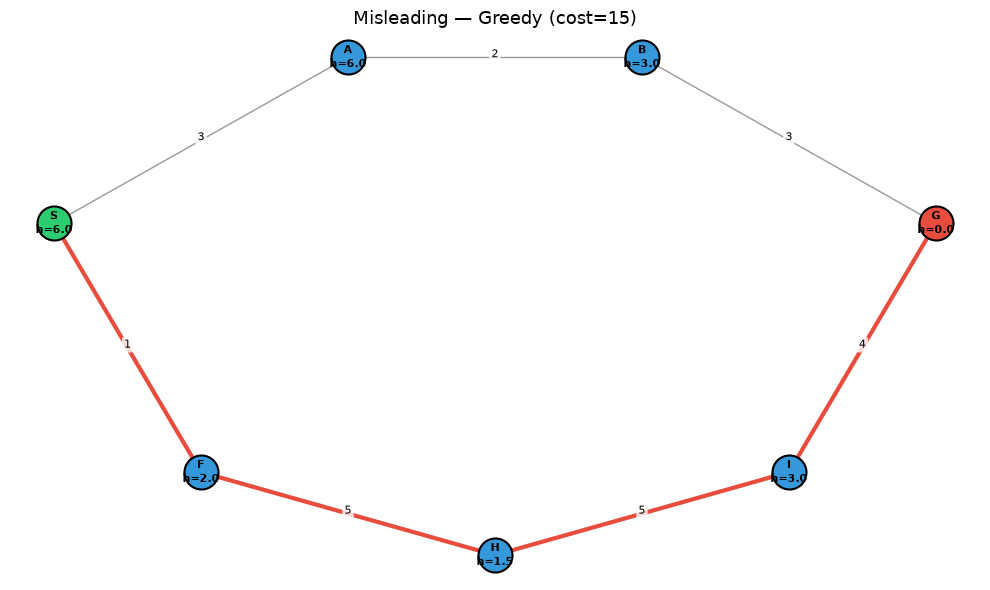

In [8]:
# Visualise BFS, DFS, and greedy paths for each graph
if not results:
    print("⚠ No results to visualise — implement bfs_search, dfs_search, and greedy_search first!")
else:
    for name, cfg in GRAPH_CONFIGS.items():
        r = results[name]
        g, pos, h = cfg['graph'], cfg['positions'], cfg['heuristic']
        s, goal = cfg['start'], cfg['goal']

        visualise_graph(g, pos, heuristic=h, start=s, goal=goal,
                        path=r['bfs_path'],
                        title=f"{name.title()} — BFS (cost={r['bfs_cost']})")
        visualise_graph(g, pos, heuristic=h, start=s, goal=goal,
                        path=r['dfs_path'],
                        title=f"{name.title()} — DFS (cost={r['dfs_cost']})")
        visualise_graph(g, pos, heuristic=h, start=s, goal=goal,
                        path=r['greedy_path'],
                        title=f"{name.title()} — Greedy (cost={r['greedy_cost']})")


### Comparison table

Fill in the table below based on your results. Hill climbing is included with n/a marks because you are not implementing it for these graph-search problems.

| Graph | Algorithm | Path | Path cost | Nodes expanded |
|-------|-----------|------|-----------|---------------|
| Sparse | BFS |[s,a,c,g] |13 |4 |
| Sparse | DFS |[s,b,d,g] |10 | 3|
| Sparse | Greedy |[s,b,d,g] |10 |4 |
| Sparse | Hill climbing | n/a | n/a | n/a |
| Dense | BFS |[s,c,g] |16 |4 |
| Dense | DFS |[s,c,g] |16 |2 |
| Dense | Greedy |[s,c,g] |16 |3 |
| Dense | Hill climbing | n/a | n/a | n/a |
| Misleading | BFS |[s,a,b,g] |8 |4 |
| Misleading | DFS |[s,f,h,i,g] |15 |4 |
| Misleading | Greedy |[s,f,h,i,g] |15 |5 |
| Misleading | Hill climbing | n/a | n/a | n/a |

### Analysis questions (~200 words total)

Answer the following:

1. On which graph(s) did BFS, DFS, and greedy find the **same** path? Why?
2. On which graph did DFS or greedy perform **worst** relative to BFS? What about the graph structure caused this?
3. Does expanding fewer nodes always mean finding a better path? Use your results to support your answer.

*(Write your answers here)*
in Dense graph where, by chance, they all go for the same route, but the expanded node is different, it just mean BFS and greedy all have pretential to be the shortest route, but the risk is still different. In missleading BFS have better path, DFS has longer route depands on the first node it looks, for greedy, it will goes to the node with lowest huristic around. Fewer node doesn;t mean better path, as we know greedy and Dfs tend to have less exppanded node, but most of the time shortest path is base on luck for this two algorithm, whereas BFS has more node expanded but always got the shortest path.
### Why is hill climbing in the table but not in the code?

Think about the difference between **graph search** (BFS, DFS, greedy) and **local search** (hill climbing):

1. What kind of problem does hill climbing solve? What kind of problem is graph routing/pathfinding?
2. Why can't you run hill climbing on these weighted graphs the same way you ran BFS, DFS, and greedy? (2–3 sentences)

*(Write your answers here)*
hill climbing solve things that might took a lot of resource to solve and doesn't expect to solve it, so it finds a "ok" solution. BFS have high node expand but have best path overall, greedy decrease the node expand but still reamin decent path length. You can run hill clmbing in the weighted graphs becasue it doesn't have violation. 

---

## Check Your Understanding

In [9]:
from jupyterquiz import display_quiz

c1_quiz = [
    {
        "question": "Why does hill climbing with random restarts work better than plain hill climbing?",
        "type": "multiple_choice",
        "answers": [
            {"answer": "Each restart begins from a different random state, so the algorithm samples many different regions of the search space — increasing the chance that at least one run avoids local minima.", "correct": True, "feedback": "Correct! Random restarts don't fix any single run, but across many runs the probability of finding the global optimum increases rapidly."},
            {"answer": "Restarts make the algorithm smarter about which neighbours to explore.", "correct": False, "feedback": "Each individual run is the same algorithm. Restarts just give it multiple independent attempts from different starting points."},
            {"answer": "Restarts increase the step size so the algorithm can escape local minima.", "correct": False, "feedback": "The step size doesn't change. What changes is the starting point — a fresh random board may land in a basin that leads to the global optimum."},
            {"answer": "Restarts allow the algorithm to backtrack to previous states.", "correct": False, "feedback": "Hill climbing with restarts does NOT backtrack — it starts completely fresh. Backtracking is a different algorithm entirely."}
        ]
    },
    {
        "question": "On the misleading graph, greedy best-first found a longer path than BFS. Why?",
        "type": "multiple_choice",
        "answers": [
            {"answer": "Greedy follows the heuristic, which pointed toward nodes that seemed close to the goal but led to a longer actual path. BFS ignores the heuristic and explores level by level.", "correct": True, "feedback": "Correct! The heuristic can be misleading — a node with low h(n) isn't necessarily on the shortest path. Greedy trusts the heuristic blindly; BFS doesn't use it at all."},
            {"answer": "BFS always finds the optimal path on any graph.", "correct": False, "feedback": "BFS finds the path with fewest edges, not necessarily the lowest total cost. On weighted graphs, BFS is not always optimal by cost."},
            {"answer": "Greedy expanded more nodes, so it wasted time on bad paths.", "correct": False, "feedback": "Greedy often expands fewer nodes than BFS. The issue isn't how many nodes it expands, but which direction the heuristic pulls it."},
            {"answer": "The misleading graph has a bug in its heuristic values.", "correct": False, "feedback": "The heuristic values are intentionally designed to be misleading — that's the point of the exercise. A heuristic can be 'wrong' in the sense that it doesn't reflect actual path costs."}
        ]
    },
    {
        "question": "BFS finds the shortest path (fewest edges), but greedy best-first often expands fewer nodes. What's the tradeoff?",
        "type": "multiple_choice",
        "answers": [
            {"answer": "BFS guarantees optimality but explores more; greedy is faster but may find a suboptimal path because it follows the heuristic greedily.", "correct": True, "feedback": "Correct! BFS explores level by level (guaranteeing shortest path), while greedy dives toward the goal (faster but not optimal). The heuristic guides greedy but can mislead it."},
            {"answer": "There is no tradeoff — greedy is strictly better.", "correct": False, "feedback": "Greedy can find longer paths than BFS. Speed isn't everything — in disaster relief, the optimal route might matter."},
            {"answer": "BFS uses less memory than greedy.", "correct": False, "feedback": "BFS typically uses MORE memory (it stores the entire frontier at each level). Greedy's frontier is usually smaller because it prioritises promising nodes."},
            {"answer": "Greedy always finds the optimal path, just faster.", "correct": False, "feedback": "Greedy does NOT guarantee optimality. It follows the heuristic, which can lead it away from the true shortest path."}
        ]
    }
]

display_quiz(c1_quiz, shuffle_answers=True)

<IPython.core.display.Javascript object>

---

## Submission Checklist

- [x ] **C1.1:** Random restarts implemented and tested
- [x ] **C1.1:** Success rate vs restarts plot
- [x ] **C1.1:** >95% reliability threshold identified
- [x ] **C1.2:** BFS, DFS, and greedy implemented for general graphs
- [x ] **C1.2:** All three graph-search algorithms run on all three graphs (sparse, dense, misleading)
- [x ] **C1.2:** Comparison table filled in
- [x ] **C1.2:** Analysis questions answered (~200 words)
- [x ] **C1.2:** Hill climbing inapplicability explained (2–3 sentences)
- [x ] All files uploaded to OnTrack

---

> **AI use at Credit level.**
> You may use AI to explain concepts or debug errors. Do not use AI to generate implementations or written analysis. Cite all AI use.
i use for debugging, the overall code is base on previous work, i will ask like give me example of getting dict value, which it use in getting neighbour.

---

*FIT1061 Credit Task 1: Search Extensions*
